# Jev vs Claude Opus: analysis and figures (v6)

Analysis only: **no model calls, no API keys needed, about 2 minutes.** Re-analyzes the existing `results.jsonl` with the v6 additions (paired significance test on top-1 accuracy, rate of zero probability on the true diagnosis, calibration figures) and commits the results.

Unchanged harness files are loaded from `code/v5/`; the two new or changed files (`analyze.py`, `plots.py`) from `code/v6/`. Every file is checked against its recorded hash. Outputs: `runs/summary.md` and `runs/figures/`.

## 1. Setup and code check

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, hashlib, json, subprocess, datetime, glob
VERSION = 'v6'
WORK = '/content/drive/MyDrive/jev_bench'
D = f'{WORK}/data'
OUT = f'{WORK}/results.jsonl'
FIG = f'{WORK}/runs/figures'
EXPECTED = {'clients.py': ('v5', '16472190f65fd6ec55e2888b89c8daf9176768a90ac5c191e13ebfb8a79f49d0'), 'run.py': ('v5', 'be272041e1e79549e93c8bdcf9c9fefa303443b561c2dd5d4c090b539a19c99e'), 'ddxplus_to_cases.py': ('v5', '0a2c9072ec480fe52e3eef4f420fcc2f37a71372d252c84a442e34a922912c51'), 'analyze.py': ('v6', '19a999923ebcb0ab75032e37802849cb513c746ed98aa9b9f9a91d75d16ab3cc'), 'plots.py': ('v6', 'b1b426a07e94fbb615d116c39ff0604d7aa2a9b9d0b8e4b9d0718efeebc35d1c')}  # file -> (code folder, sha256)

def sha(path):
    return hashlib.sha256(open(path, 'rb').read()).hexdigest()

RUN = '/content/jev_bench'
os.makedirs(RUN, exist_ok=True)
bad = []
for f, (folder, h) in EXPECTED.items():
    p = f'{WORK}/code/{folder}/{f}'
    if not os.path.exists(p):
        bad.append(f'{folder}/{f}: missing')
    elif sha(p) != h:
        bad.append(f'{folder}/{f}: hash mismatch')
    else:
        shutil.copy(p, f'{RUN}/{f}')
if bad:
    raise SystemExit('Code check FAILED, paste this to Claude:\n' + '\n'.join(bad))
os.chdir(RUN)
print('All', len(EXPECTED), 'files verified for', VERSION)

Mounted at /content/drive
All 5 files verified for v6


## 2. Version control

In [2]:
GOOGLE_NATIVE = ('.gsheet', '.gdoc', '.gslides', '.gform', '.gdraw', '.gmap', '.gsite', '.gjam')

def _git(*args):
    return subprocess.run(['git', '-C', WORK, *args], capture_output=True, text=True)

def _safe_sha(p):
    try:
        return sha(p)
    except OSError as e:
        return f'unreadable: {e.strerror}'

def _notebook_json():
    try:
        from google.colab import _message
        return _message.blocking_request('get_ipynb', request='', timeout_sec=30)['ipynb']
    except Exception as e:
        print('  (could not capture notebook contents:', e, ')')
        return None

def snapshot(label):
    stamp = datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%dT%H%M%SZ')
    os.makedirs(f'{WORK}/runs', exist_ok=True)
    nbj = _notebook_json()
    if nbj:
        json.dump(nbj, open(f'{WORK}/runs/notebook_snapshot.ipynb', 'w'), indent=1)
    manifest = {'label': label, 'utc': stamp, 'version': VERSION,
                'code_sha256': {f'{d}/{f}': h for f, (d, h) in EXPECTED.items()},
                'data_sha256': {os.path.relpath(p, WORK): _safe_sha(p)
                                for p in sorted(glob.glob(f'{D}/**/*', recursive=True))
                                if os.path.isfile(p) and not p.endswith(GOOGLE_NATIVE)},
                'results_sha256': sha(OUT) if os.path.exists(OUT) else None}
    json.dump(manifest, open(f'{WORK}/runs/MANIFEST.json', 'w'), indent=2)
    vdir = f'{WORK}/versions/{stamp}_{label}'
    os.makedirs(vdir, exist_ok=True)
    shutil.copy(f'{WORK}/runs/MANIFEST.json', vdir)
    _git('add', '-A')
    c = _git('commit', '-q', '-m', f'{VERSION} {label} {stamp}')
    head = _git('rev-parse', '--short', 'HEAD').stdout.strip()
    print(f'snapshot "{label}": commit {head}' + ('' if c.returncode == 0 else ' (no changes)'))

snapshot('setup')

snapshot "setup": commit 31cf144


## 3. Analysis and figures

In [3]:
sh = get_ipython().system
extra = f'--cases {D}/ddxplus_cases.csv' if os.path.exists(f'{D}/ddxplus_cases.csv') else ''
sh(f'python analyze.py {OUT} {extra} > {WORK}/runs/summary.md')
sh(f'python plots.py {OUT} --outdir {FIG}')
print(open(f'{WORK}/runs/summary.md').read())

wrote reliability_ddxplus.png and .csv
wrote reliability_semigran45.png and .csv
# Results summary

Harness commit(s): 483889f, 54988ba, 79850b7, 8965c7b, 9ab7e87, b0e1890, ef4e15e
Resolved model versions: jev=typesafe/jev-1.13-20260917, opus5_nothink=claude-opus-5, opus_verbalized=claude-opus-5-5

## Output resolution (Amendment 1, descriptive)

- jev: exact-zero rate 93.1%; values on a 0.01 grid 99.1%; smallest nonzero 0.01 (n=71785)
- opus5_nothink: exact-zero rate 0.0%; values on a 0.01 grid 0.3%; smallest nonzero 0.0001 (n=71785)
- opus_verbalized: exact-zero rate 2.7%; values on a 0.01 grid 3.7%; smallest nonzero 0.0001 (n=71785)

## Token usage (v5, where recorded)

- opus5_nothink: n=1600; thinking tokens median 0 (IQR 0 to 0), share of calls with any thinking 0.0%; output tokens median 659
- opus_verbalized: n=1000; thinking tokens median 0 (IQR 0 to 197), share of calls with any thinking 41.2%; output tokens median 691
- Excluded from analysis: opus_sampled,opus_sampled_v2

#

reliability_ddxplus.png


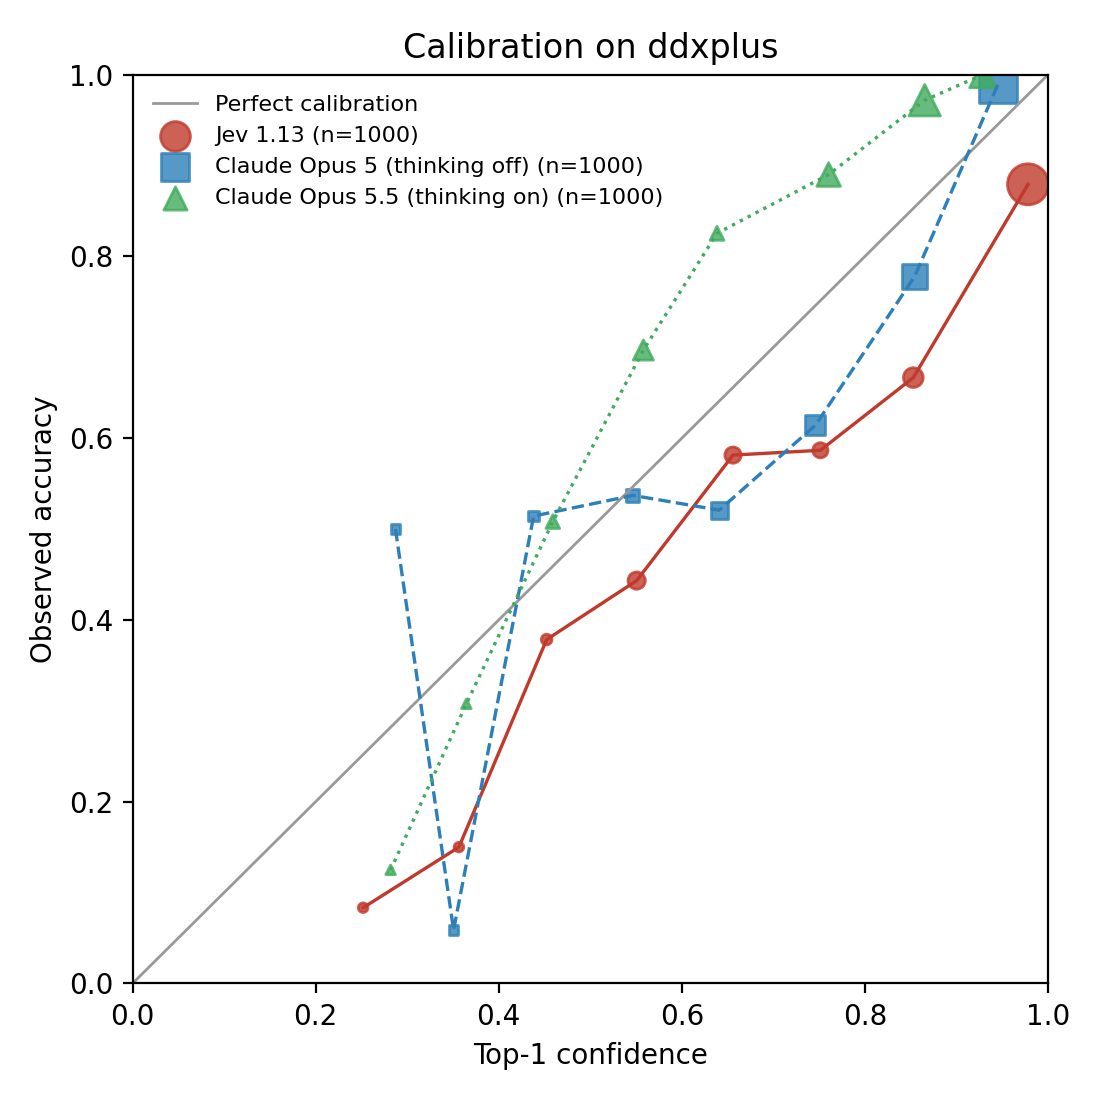

reliability_semigran45.png


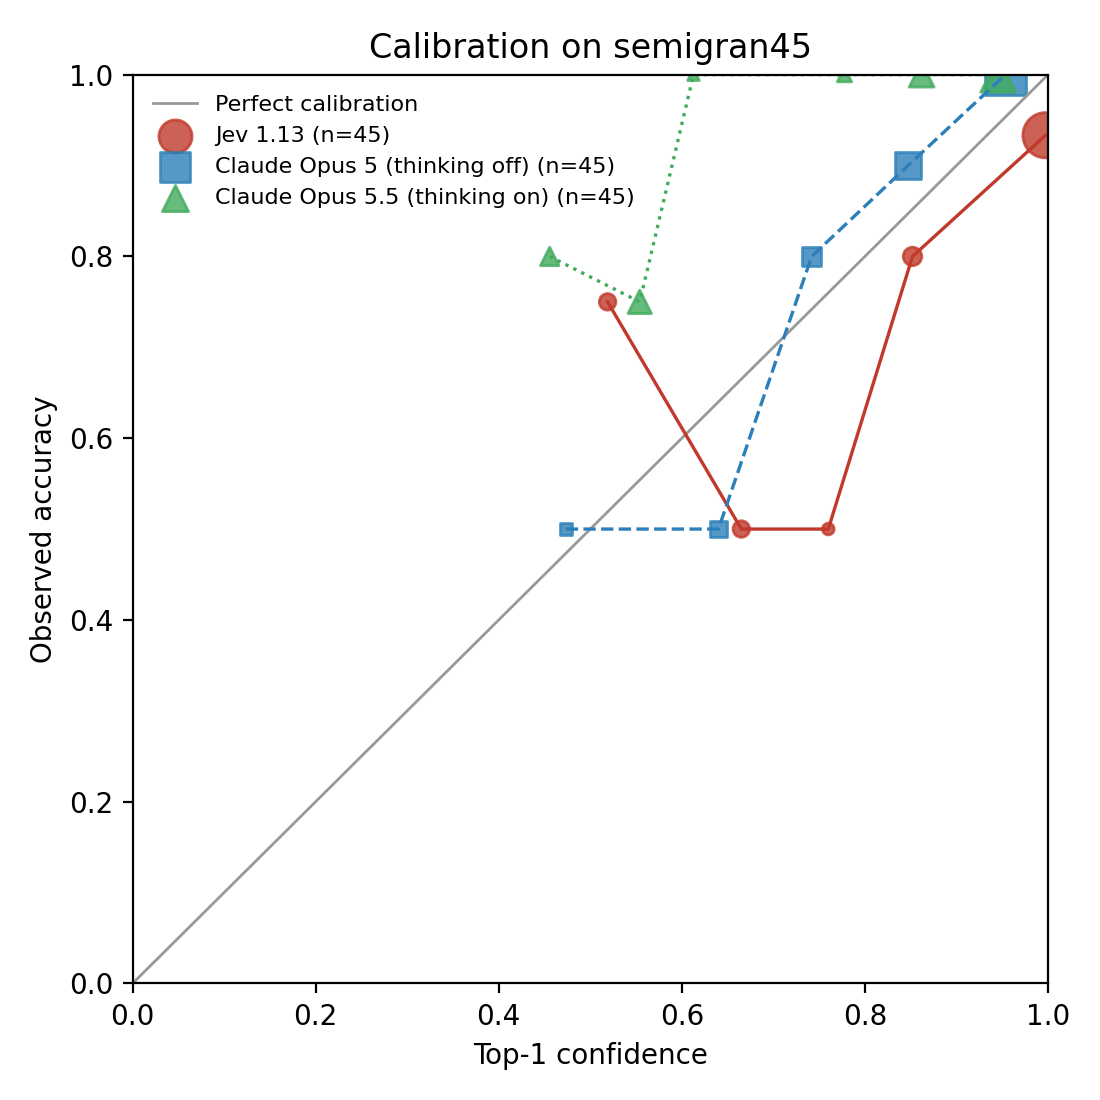

snapshot "analysis-v6": commit 570ece3
570ece3 v6 analysis-v6 20260927T202331Z
31cf144 v6 setup 20260927T201809Z
9160b8f v5 analysis 20260927T200729Z
79850b7 v5 pre-run-ddxplus 20260927T161513Z
483889f v5 pre-run-opus5-nothink 20260927T161504Z



In [4]:
from IPython.display import Image, display
for p in sorted(glob.glob(f'{FIG}/*.png')):
    print(os.path.basename(p)); display(Image(p, width=450))
snapshot('analysis-v6')
print(_git('log', '--oneline', '-5').stdout)